In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')

**1.Data Processing**

In [27]:
# Load the data set
df = pd.read_csv('tips (1).csv')

#Explore data types
print(f"\n✅ Loaded {len(df)} homes")
print(f"\nDataset overview:")
print(df.info())

# Check missing values in each column
print("\n Checking for missing values:")
print(df.isnull().sum())



✅ Loaded 244 homes

Dataset overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
 7   Payer Name  244 non-null    object 
 8   CC Number   244 non-null    int64  
 9   Payment ID  244 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 19.2+ KB
None

 Checking for missing values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
Payer Name    0
CC Number     0
Payment ID    0
dtype: int64


In [28]:
#Clean the dataset
df = df.drop(['Payer Name', 'CC Number', 'Payment ID'], axis=1)
print("✅ Personal identifiers removed.")
print(df.head())


✅ Personal identifiers removed.
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [29]:
#Convert categorical variables
print("\n Creating dummy variables for all categorical features...")

df_dummies = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True, dtype=int)

print(df_dummies.head())



 Creating dummy variables for all categorical features...
   total_bill   tip  size  sex_Male  smoker_Yes  day_Sat  day_Sun  day_Thur  \
0       16.99  1.01     2         0           0        0        1         0   
1       10.34  1.66     3         1           0        0        1         0   
2       21.01  3.50     3         1           0        0        1         0   
3       23.68  3.31     2         1           0        0        1         0   
4       24.59  3.61     4         0           0        0        1         0   

   time_Lunch  
0           0  
1           0  
2           0  
3           0  
4           0  


**Descriptive Analytics**

1.Does tipping behavior vary between lunch and dinner?

In [11]:
# Compare mean and median tips for lunch vs dinner
print(df.groupby("time")["tip"].agg(["mean", "median", "count"]))


            mean  median  count
time                           
Dinner  3.102670    3.00    176
Lunch   2.728088    2.25     68


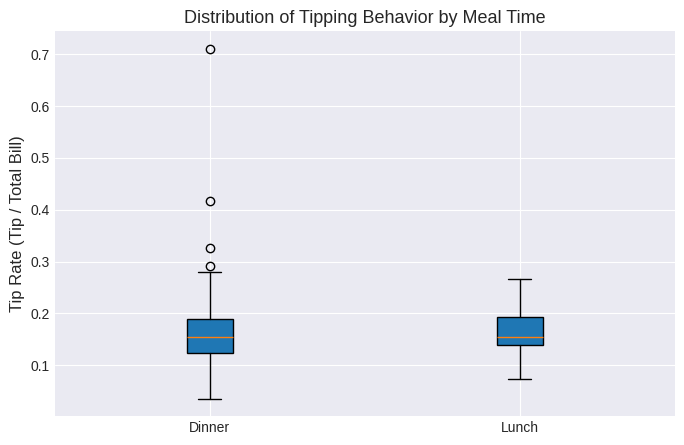

In [30]:
# Create a box plot for tip rates by meal time
df["tip_rate"] = df["tip"] / df["total_bill"]
time_names = df["time"].unique()

# Create a list of tip rate data for each time
time_data = [df[df["time"] == t]["tip_rate"] for t in time_names]

# Plot the box plot
plt.figure(figsize=(8, 5))
plt.boxplot(time_data, tick_labels=time_names, patch_artist=True)

plt.ylabel("Tip Rate (Tip / Total Bill)", fontsize=12)
plt.title("Distribution of Tipping Behavior by Meal Time", fontsize=13)
plt.show()


        mean  median  count
time                       
Dinner  3.10    3.00    176
Lunch   2.73    2.25     68


/tmp/ipython-input-2627902855.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="tip", data=df, palette="coolwarm")


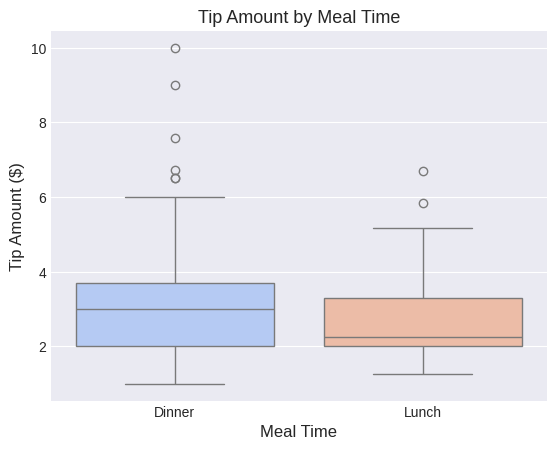

In [31]:
# Compare tip amount by meal time
print(df.groupby("time")["tip"].agg(["mean", "median", "count"]).round(2))

# Create a Seaborn boxplot for tip amount
sns.boxplot(x="time", y="tip", data=df, palette="coolwarm")

plt.title("Tip Amount by Meal Time", fontsize=13)
plt.xlabel("Meal Time", fontsize=12)
plt.ylabel("Tip Amount ($)", fontsize=12)
plt.show()


[3.1  2.73] Index(['Dinner', 'Lunch'], dtype='object', name='time')


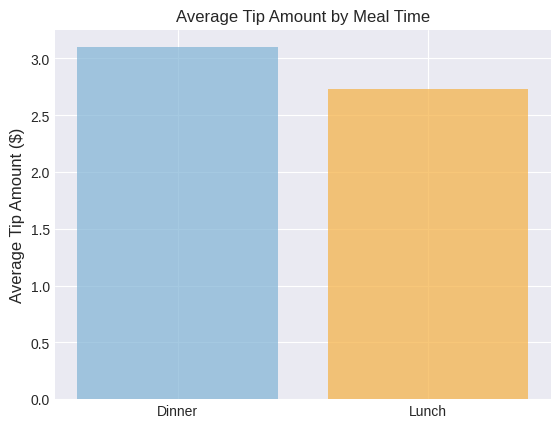

In [32]:
# Create a bar chart: average tip by meal time
tip_stats = df.groupby('time')['tip'].agg(['mean', 'std', 'count']).round(2)
tip_means = tip_stats['mean'].values
time_names = tip_stats.index

print(tip_means, time_names)

plt.bar(time_names, tip_means, color=['#7FB3D5', '#F5B041'], alpha=0.7)
plt.ylabel('Average Tip Amount ($)', fontsize=12)
plt.title('Average Tip Amount by Meal Time')
plt.xticks(rotation=0)
plt.show()


In [62]:
# Define a function to test statistical significance between two groups
def test_statistical_significance(group1, group2, alpha=0.05):
    # Perform independent samples t-test
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"📊 TEST RESULTS: t-statistic = {t_stat:.3f},  p-value = {p_value:.4f}")

    # Interpret results
    if p_value < alpha:
        print("✅ Result: Statistically significant difference (reject H₀)")
    else:
        print("❌ Result: No statistically significant difference (fail to reject H₀)")

    return p_value



df["tip_rate"] = df["tip"] / df["total_bill"]

# Create groups for each meal time
lunch_tips = df[df["time"] == "Lunch"]["tip_rate"]
dinner_tips = df[df["time"] == "Dinner"]["tip_rate"]

# Compare Lunch vs Dinner
print(" Lunch vs Dinner")
p = test_statistical_significance(lunch_tips, dinner_tips)

 Lunch vs Dinner
📊 TEST RESULTS: t-statistic = 0.654,  p-value = 0.5138
❌ Result: No statistically significant difference (fail to reject H₀)


The samples t-test comparing tip rates between Lunch and Dinner yielded a p-value of 0.51, indicating no statistically significant difference.
This suggests that, while dinner bills are typically larger and lead to higher tip amounts according to boxplots, customers tend to tip at roughly the same percentage of their total bill during both Lunch and Dinner.

In [35]:
# Convert meal time to numeric for correlation
df["time_num"] = df["time"].map({"Lunch": 0, "Dinner": 1})

# Calculate correlation coefficient between meal time and tip amount
correlation_r = df["time_num"].corr(df["tip"])

print(f"\n CORRELATION COEFFICIENT:")
print(f"    r = {correlation_r:.3f}")

# Interpret the correlation
print(f"\n INTERPRETING CORRELATION:")
if abs(correlation_r) < 0.3:
    strength = "WEAK"
elif abs(correlation_r) < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"

print(f"    Strength: {strength} {'positive' if correlation_r > 0 else 'negative'} relationship")
print(f"    Direction: As we move from Lunch (0) to Dinner (1), tip amount tends to "
      f"{'increase' if correlation_r > 0 else 'decrease'}.")




 CORRELATION COEFFICIENT:
    r = 0.122

 INTERPRETING CORRELATION:
    Strength: WEAK positive relationship
    Direction: As we move from Lunch (0) to Dinner (1), tip amount tends to increase.


2.Do larger parties tend to tip more?

In [63]:
# Compare mean and median tip amount by party size
tip_summary = df.groupby("size")["tip"].agg(["mean", "median", "std", "count"]).round(2)
print(" Tip Summary by Party Size")
print(tip_summary)


 Tip Summary by Party Size
      mean  median   std  count
size                           
1     1.44    1.42  0.51      4
2     2.58    2.50  0.99    156
3     3.39    3.29  1.56     38
4     4.14    3.76  1.64     37
5     4.03    5.00  1.44      5
6     5.22    5.00  1.05      4


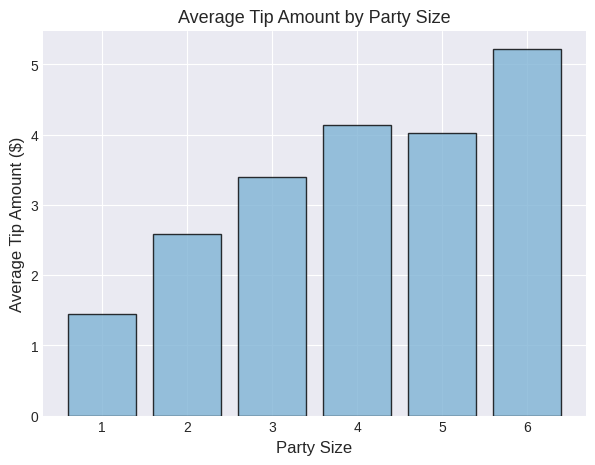

In [64]:
# Group data by party size and calculate average tip
size_stats = df.groupby("size")["tip"].agg(["mean", "std", "count"]).round(2)

# Extract mean values and labels
size_means = size_stats["mean"].values
size_labels = size_stats.index


# Create the bar chart
plt.figure(figsize=(7,5))
plt.bar(size_labels, size_means, color="#7FB3D5", alpha=0.8, edgecolor="black")

plt.ylabel("Average Tip Amount ($)", fontsize=12)
plt.xlabel("Party Size", fontsize=12)
plt.title("Average Tip Amount by Party Size", fontsize=13)
plt.show()


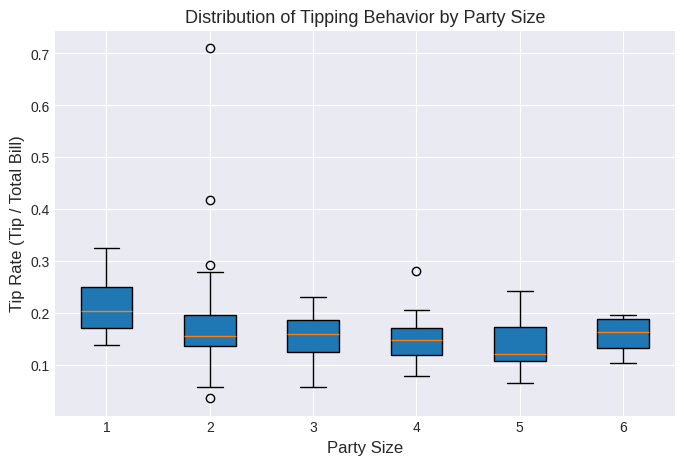

In [65]:
# Create a box plot for tip rates by party size
df["tip_rate"] = df["tip"] / df["total_bill"]

# Unique party sizes
size_names = sorted(df["size"].unique())

# Create a list of tip rate data for each party size
size_data = [df[df["size"] == s]["tip_rate"] for s in size_names]

# Plot the box plot
plt.figure(figsize=(8, 5))
plt.boxplot(size_data, tick_labels=size_names, patch_artist=True)

plt.ylabel("Tip Rate (Tip / Total Bill)", fontsize=12)
plt.xlabel("Party Size", fontsize=12)
plt.title("Distribution of Tipping Behavior by Party Size", fontsize=13)
plt.show()


      mean  median  count
size                     
1     1.44    1.42      4
2     2.58    2.50    156
3     3.39    3.29     38
4     4.14    3.76     37
5     4.03    5.00      5
6     5.22    5.00      4


/tmp/ipython-input-3805036548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="size", y="tip", data=df, palette="coolwarm")


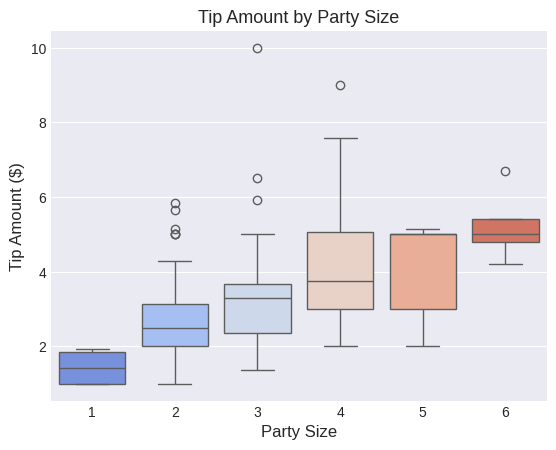

In [39]:
# Compare tip amount by party size
print(df.groupby("size")["tip"].agg(["mean", "median", "count"]).round(2))

# Create a Seaborn boxplot for tip amount
sns.boxplot(x="size", y="tip", data=df, palette="coolwarm")

plt.title("Tip Amount by Party Size", fontsize=13)
plt.xlabel("Party Size", fontsize=12)
plt.ylabel("Tip Amount ($)", fontsize=12)
plt.show()


In [66]:
# Define the same test function (reuse this if already defined)
def test_statistical_significance(group1, group2, alpha=0.05):
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    print(f"📊 TEST RESULTS: t-statistic = {t_stat:.3f},  p-value = {p_value:.4f}")

    if p_value < alpha:
        print("✅ Result: Statistically significant difference (reject H₀)")
    else:
        print("❌ Result: No statistically significant difference (fail to reject H₀)")
    return p_value


# Create groups for small and large parties
small_party_tips = df[df["size"] <= 2]["tip"]
large_party_tips = df[df["size"] >= 4]["tip"]

# Compare small vs large parties
print("👥 Small Parties (1-2) vs Large Parties (4+)")
p = test_statistical_significance(small_party_tips, large_party_tips)


👥 Small Parties (1-2) vs Large Parties (4+)
📊 TEST RESULTS: t-statistic = -6.755,  p-value = 0.0000
✅ Result: Statistically significant difference (reject H₀)



💡 CORRELATION COEFFICIENT:
    r = 0.489

 INTERPRETING CORRELATION:
    Strength: MODERATE positive relationship
    Direction: As party size increases, tip amount tends to increase.


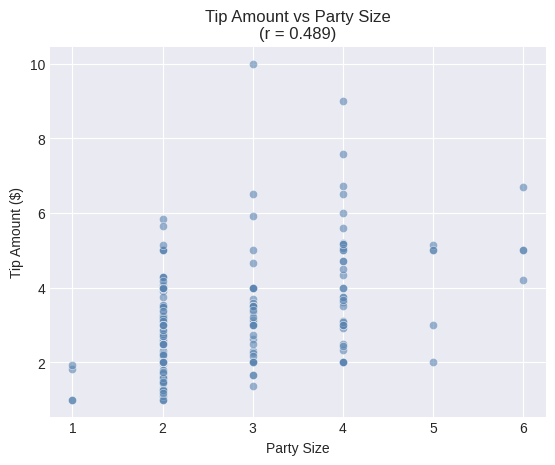

In [67]:
# Calculate correlation coefficient between party size and tip amount
correlation_r = df['size'].corr(df['tip'])

print(f"\n💡 CORRELATION COEFFICIENT:")
print(f"    r = {correlation_r:.3f}")

# Interpret the correlation
print(f"\n INTERPRETING CORRELATION:")
if abs(correlation_r) < 0.3:
    strength = "WEAK"
elif abs(correlation_r) < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"

print(f"    Strength: {strength} {'positive' if correlation_r > 0 else 'negative'} relationship")
print(f"    Direction: As party size increases, tip amount tends to "
      f"{'increase' if correlation_r > 0 else 'decrease'}.")

# Visualize correlation using scatterplot
sns.scatterplot(x='size', y='tip', data=df, color='#5B84B1', alpha=0.6)
plt.xlabel('Party Size')
plt.ylabel('Tip Amount ($)')
plt.title(f'Tip Amount vs Party Size\n(r = {correlation_r:.3f})')
plt.show()


Analysis of tipping patterns by party size reveals that larger groups tend to leave higher tip bills, but not necessarily higher tip rates. As the number of diners increases, the overall tip amount rises mainly because the total bill is larger, not because each person tips more generously. The positive but modest correlation between party size and tip amount supports this trend.

**Develop a Multiple Regression Model**

I will conduct three regression models and pick the best fit.

In [46]:
# 1.Tip predicted only by total_bill
model1 = sm.OLS(df['tip'], sm.add_constant(df['total_bill'])).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           6.69e-34
Time:                        03:56:25   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

In [73]:
#2.Tip predicted by total_bill and size
X2 = df[['total_bill', 'size']]
X2 = sm.add_constant(X2)
model2 = sm.OLS(df['tip'], X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           9.67e-34
Time:                        04:48:15   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6689      0.194      3.455      0.0

In [74]:
# 3.Tip predicted by total_bill,size, day and time
#Outcome variable
y = df_dummies['tip']

# Predictor variables:
# total_bill, size, day dummies, and time dummies
day_cols = [col for col in df_dummies.columns if col.startswith('day_')]
time_cols = [col for col in df_dummies.columns if col.startswith('time_')]

X = df_dummies[['total_bill', 'size'] + day_cols + time_cols]

# Add intercept term
X = sm.add_constant(X)

# Fit multiple linear regression model using sm
model3 = sm.OLS(y, X).fit()

# Show regression summary
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     34.91
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           4.12e-30
Time:                        04:48:27   Log-Likelihood:                -347.69
No. Observations:                 244   AIC:                             709.4
Df Residuals:                     237   BIC:                             733.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7266      0.329      2.207      0.0

**What is the impact of total_bill on tip?**
For every $1 increase in the total bill, the tip increases by about 9.3 cents, holding party size and day constant.
The effect is statistically significant(p<0.05), showing that customers tip more as their bill increases.

**Do larger parties tend to tip more?**
For every additional person in the party, the tip increases by about $0.1865, controlling for bill amount and other variables.The effect is statistically significant(p<0.05), showing that customers tip more as the size increases.

**Does tipping behavior vary across various days?**
Because the p-value is extremely large(P>0.05), there is no meaningful difference in tipping behavior across different days of the week or between lunch and dinner, after controlling for total bill and party size.

As the second one has the highest adjusted R square and the coefficients are all statistically significant, I will pick it to be my predictive model.

**Make Predictions and Evaluate**

In [75]:
# Make predictions with my regression model
y_pred = model2.predict(X2)


In [76]:
# Compute key performance metrics
r2 = model2.rsquared
rmse = model2.resid.std()

print("\n💡 MULTIPLE REGRESSION RESULTS:")
print(f"  Intercept (b₀): ${model2.params.iloc[0]:.2f}")
for i, col in enumerate(model2.params.index[1:]):
    print(f"  Coefficient for {col}: {model2.params.iloc[i+1]:.3f}")

print("\n MODEL PERFORMANCE:")
print(f"  R²   = {r2:.4f}")
print(f"  RMSE = ${rmse:.2f}")



💡 MULTIPLE REGRESSION RESULTS:
  Intercept (b₀): $0.67
  Coefficient for total_bill: 0.093
  Coefficient for size: 0.193

 MODEL PERFORMANCE:
  R²   = 0.4679
  RMSE = $1.01


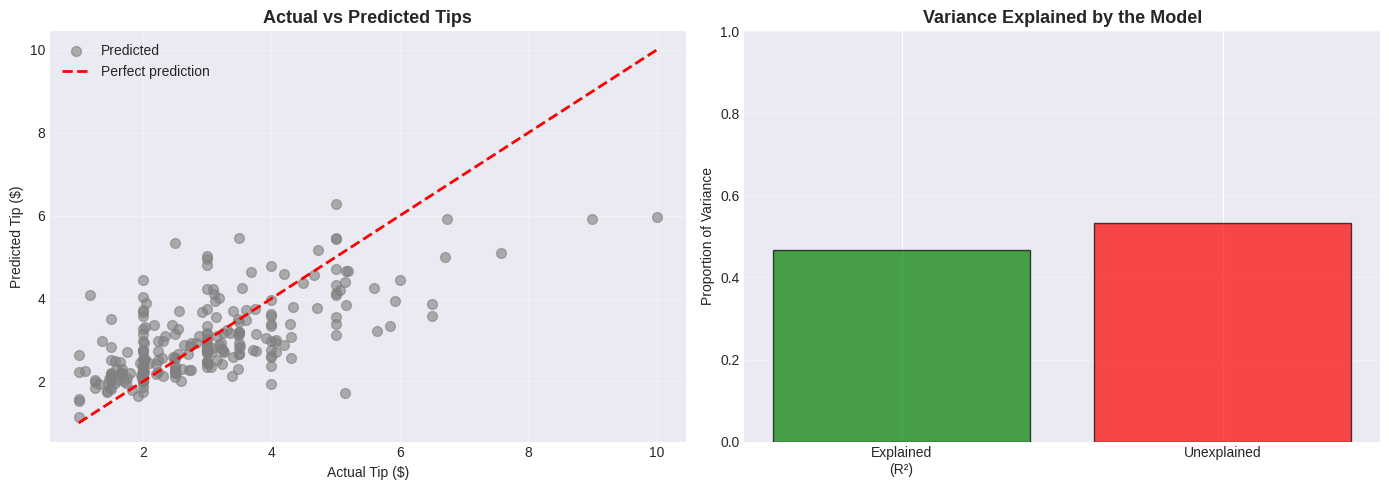

In [77]:
# Visualize actual vs predicted tips and variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Actual vs Predicted comparison ----
axes[0].scatter(y, y_pred, alpha=0.6, s=50, color="gray", label="Predicted")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()],
             "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Tip ($)")
axes[0].set_ylabel("Predicted Tip ($)")
axes[0].set_title("Actual vs Predicted Tips", fontweight="bold", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: R² vs Unexplained variance ----
explained = r2
unexplained = 1 - r2

labels = ["Explained\n(R²)", "Unexplained"]
values = [explained, unexplained]
colors = ["green", "red"]

axes[1].bar(labels, values, color=colors, alpha=0.7, edgecolor="black")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Proportion of Variance")
axes[1].set_title("Variance Explained by the Model", fontweight="bold", fontsize=13)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [78]:
# Comment on the model’s predictive power
if r2 > 0.7:
    comment = "The model has strong predictive power."
elif r2 > 0.4:
    comment = "The model has moderate predictive power, capturing main patterns but leaving room for improvement."
else:
    comment = "The model has weak predictive power."

print(f"\n COMMENT: {comment}")


 COMMENT: The model has moderate predictive power, capturing main patterns but leaving room for improvement.
